In [ ]:
!mkdir FUTURE_ML_01

In [ ]:
!ls

FUTURE_ML_01  sample_data


In [ ]:
!mkdir FUTURE_ML_01/images

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv("/content/FUTURE_ML_01/walmart/Walmart.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

df.dropna(inplace=True)

print("\nAfter Cleaning:")
print(df.shape)

(6435, 8)

Missing Values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

After Cleaning:
(6435, 8)


In [ ]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d-%m-%Y'
)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5


In [ ]:
X = df[
    [
        'Store',
        'Holiday_Flag',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment',
        'Year',
        'Month',
        'Day'
    ]
]

y = df['Weekly_Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, pred)

mse = mean_squared_error(y_test, pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, pred)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 58078.98642338773
RMSE : 116210.05824650699
R2 Score : 0.958079819067563


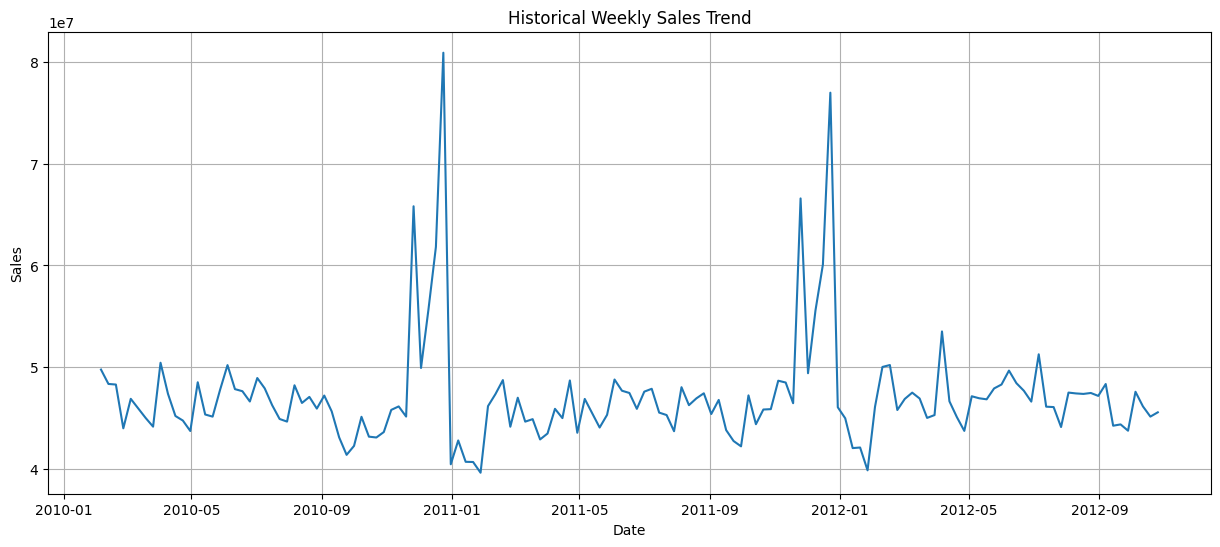

In [ ]:
plt.figure(figsize=(15,6))

sales_by_date = df.groupby('Date')['Weekly_Sales'].sum()

plt.plot(
    sales_by_date.index,
    sales_by_date.values
)

plt.title("Historical Weekly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid()

plt.show()

In [ ]:
future_dates = pd.date_range(
    start=df['Date'].max(),
    periods=30,
    freq='W'
)

future_df = pd.DataFrame()

future_df['Date'] = future_dates

future_df['Store'] = 1

future_df['Holiday_Flag'] = 0

future_df['Temperature'] = df['Temperature'].mean()

future_df['Fuel_Price'] = df['Fuel_Price'].mean()

future_df['CPI'] = df['CPI'].mean()

future_df['Unemployment'] = df['Unemployment'].mean()

future_df['Year'] = future_df['Date'].dt.year

future_df['Month'] = future_df['Date'].dt.month

future_df['Day'] = future_df['Date'].dt.day

In [ ]:
future_sales = model.predict(
    future_df[
        [
            'Store',
            'Holiday_Flag',
            'Temperature',
            'Fuel_Price',
            'CPI',
            'Unemployment',
            'Year',
            'Month',
            'Day'
        ]
    ]
)

future_df['Forecasted_Sales'] = future_sales

future_df.head()

,Date,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,Forecasted_Sales
0,2012-10-28,1,0,60.663782,3.358607,171.578394,7.999151,2012,10,28,1.841104e+06
1,2012-11-04,1,0,60.663782,3.358607,171.578394,7.999151,2012,11,4,1.980154e+06
2,2012-11-11,1,0,60.663782,3.358607,171.578394,7.999151,2012,11,11,1.975112e+06
3,2012-11-18,1,0,60.663782,3.358607,171.578394,7.999151,2012,11,18,1.960789e+06
4,2012-11-25,1,0,60.663782,3.358607,171.578394,7.999151,2012,11,25,2.653232e+06


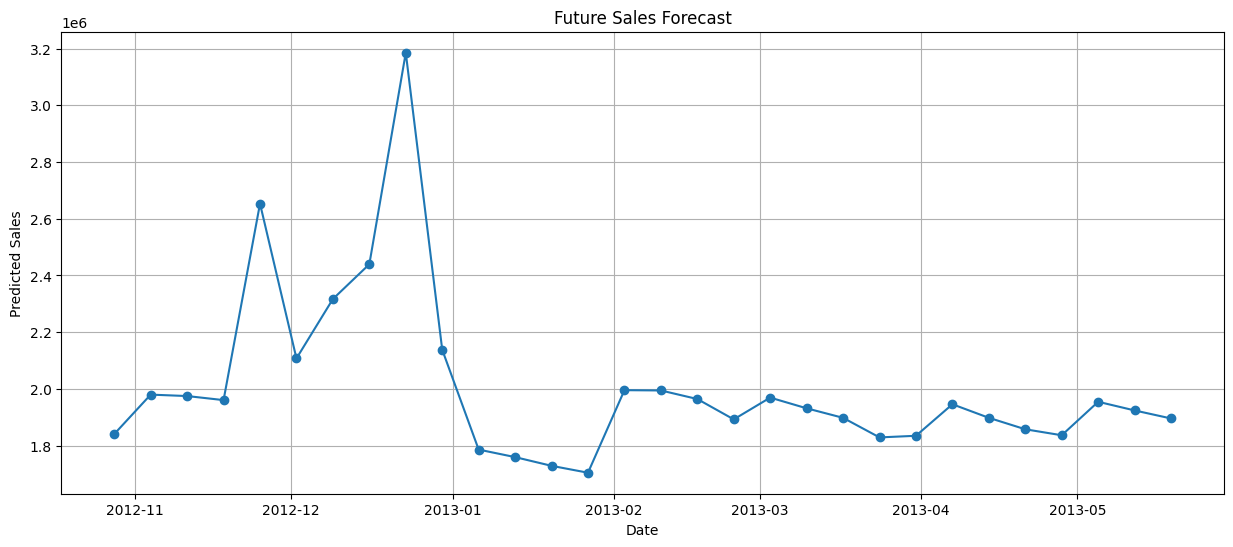

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    future_df['Date'],
    future_df['Forecasted_Sales'],
    marker='o'
)

plt.title("Future Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Predicted Sales")

plt.grid()

plt.show()

In [ ]:
readme_content = """
# Sales & Demand Forecasting for Businesses

## Objective
Build a Machine Learning model to forecast future sales using historical Walmart sales data.

## Dataset
Walmart Weekly Sales Dataset

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Project Workflow
1. Data Collection
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Model Building using Random Forest Regressor
6. Model Evaluation
7. Future Sales Forecasting
8. Visualization of Results

## Features Used
- Store
- Holiday_Flag
- Temperature
- Fuel_Price
- CPI
- Unemployment
- Year
- Month
- Day

## Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## Business Insights
- Sales trends vary across different stores.
- Holiday periods significantly affect sales.
- Economic indicators such as CPI and unemployment impact demand.
- Forecasting helps optimize inventory and business planning.
- Data-driven decisions can improve operational efficiency.

## Results
The Random Forest model was trained on historical Walmart sales data and used to forecast future sales trends. The model performance was evaluated using MAE, RMSE, and R² Score.

## Author
Tejaswini Malladi
Future Interns - Machine Learning Internship
"""

with open("README.md", "w") as file:
    file.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [ ]:
!ls

FUTURE_ML_01  README.md  sample_data


In [ ]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("/content/FUTURE_ML_01/walmart/Walmart.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.savefig("sales_trend.png")
plt.savefig("forecast.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
!ls

forecast.png  FUTURE_ML_01  README.md  sales_trend.png	sample_data
